In [19]:
pip install yfinance pandas pandas_datareader datetime numpy matplotlib

  Using cached matplotlib-3.10.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.56.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (101 kB)
  Using cached kiwisolver-1.4.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.2 kB)
Using cached matplotlib-3.10.1-cp313-cp313-macosx_11_0_arm64.whl (8.0 MB)
Using cached contourpy-1.3.1-cp313-cp313-macosx_11_0_arm64.whl (255 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.56.0-cp313-cp313-macosx_10_13_universal2.whl (2.7 MB)
Using cached kiwisolver-1.4.8-cp313-cp313-macosx_11_0_arm64.whl (65 kB)

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.3.6/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
import yfinance as yf
import pandas as pd
from pandas_datareader import data as pdr
import datetime as dt
import numpy as np
import matplotlib
print("Imported Succesfully!!!")

Imported Succesfully!!!


In [7]:
endDate = dt.datetime.now()

startDate = endDate - dt.timedelta(days = 365*5)
endDate, startDate

(datetime.datetime(2025, 3, 24, 12, 34, 1, 677572),
 datetime.datetime(2020, 3, 25, 12, 34, 1, 677572))

In [8]:
stocks = ['MSFT', 'SPY', 'QQQ']

In [9]:
df = yf.download(stocks, start = startDate, end = endDate, auto_adjust=False, actions=True)

[*********************100%***********************]  3 of 3 completed


In [10]:
df.head()

Price        Adj Close                         Capital Gains            Close  \
Ticker            MSFT         QQQ         SPY           QQQ  SPY        MSFT   
Date                                                                            
2020-03-25  140.628647  177.176468  229.460220           0.0  0.0  146.919998   
2020-03-26  149.425186  186.506622  242.858337           0.0  0.0  156.110001   
2020-03-27  143.289627  180.092133  235.624634           0.0  0.0  149.699997   
2020-03-30  153.368713  186.642654  243.276749           0.0  0.0  160.229996   
2020-03-31  150.956665  185.048767  239.650574           0.0  0.0  157.710007   

Price                              Dividends       ...         Low  \
Ticker             QQQ         SPY      MSFT  QQQ  ...         SPY   
Date                                               ...               
2020-03-25  182.300003  246.789993       0.0  0.0  ...  239.750000   
2020-03-26  191.899994  261.200012       0.0  0.0  ...  249.050003   
2020-03-27  185.300003  253.419998       0.0  0.0  ...  251.050003   
2020-03-30  192.039993  261.649994       0.0  0.0  ...  253.529999   
2020-03-31  190.399994  257.750000       0.0  0.0  ...  256.220001   

Price             Open                         Stock Splits            \
Ticker            MSFT         QQQ         SPY         MSFT  QQQ  SPY   
Date                                                                    
2020-03-25  148.910004  184.419998  244.869995          0.0  0.0  0.0   
2020-03-26  148.399994  183.869995  249.520004          0.0  0.0  0.0   
2020-03-27  151.750000  186.929993  253.270004          0.0  0.0  0.0   
2020-03-30  152.440002  187.059998  255.699997          0.0  0.0  0.0   
2020-03-31  159.399994  191.720001  260.559998          0.0  0.0  0.0   

Price         Volume                       
Ticker          MSFT       QQQ        SPY  
Date                                       
2020-03-25  75638200  88754900  299430300  
2020-03-26  64568100  79887600  257632800  
2020-03-27  57042300  58845000  224341200  
2020-03-30  63420300  49356900  171369500  
2020-03-31  77927200  62659300  194881100  

[5 rows x 26 columns]

In [11]:
adj_closed_prices = df['Adj Close']

In [12]:
adj_closed_prices.head()

Ticker,MSFT,QQQ,SPY
Date,,,
2020-03-25,140.628647,177.176468,229.460220
2020-03-26,149.425186,186.506622,242.858337
2020-03-27,143.289627,180.092133,235.624634
2020-03-30,153.368713,186.642654,243.276749
2020-03-31,150.956665,185.048767,239.650574


In [13]:
log_returns = np.log(adj_closed_prices/adj_closed_prices.shift(1))
log_returns.head()

Ticker,MSFT,QQQ,SPY
Date,,,
2020-03-25,NaN,NaN,NaN
2020-03-26,0.060673,0.051321,0.056749
2020-03-27,-0.041928,-0.034998,-0.030238
2020-03-30,0.067977,0.035727,0.031960
2020-03-31,-0.015852,-0.008576,-0.015018


In [15]:
cumulative_log_returns = log_returns.cumsum()
cumulative_log_returns.head()

Ticker,MSFT,QQQ,SPY
Date,,,
2020-03-25,NaN,NaN,NaN
2020-03-26,0.060673,0.051321,0.056749
2020-03-27,0.018745,0.016322,0.026510
2020-03-30,0.086722,0.052050,0.058470
2020-03-31,0.070870,0.043473,0.043452


<Axes: title={'center': 'Cumulative Returns'}, xlabel='Date'>

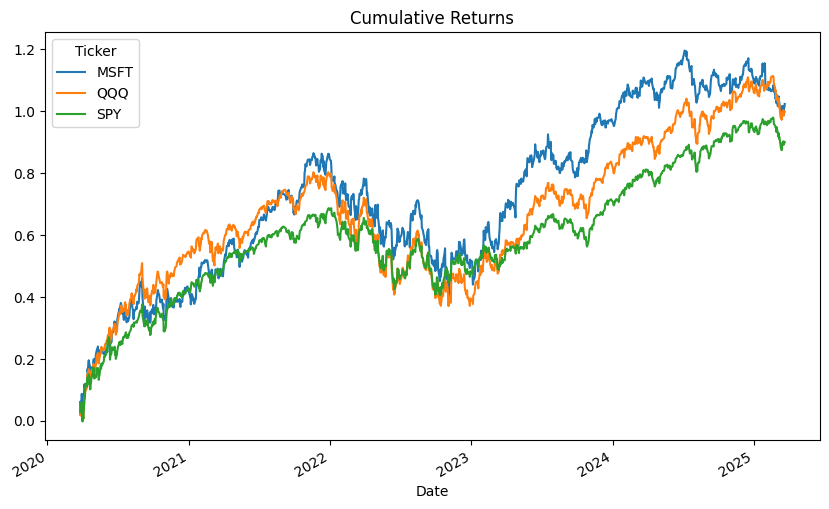

In [21]:
cumulative_log_returns.plot(title = "Cumulative Returns", figsize = (10,6))